# 📘 Chapter 8 — Dimensionality Reduction

## Topic 1 — The Curse of Dimensionality

---

## A) Where to Read

In `8_Dimensionality Reduction.pdf`:
* Section: **"The Curse of Dimensionality"**
* Look for: high-dimensional spaces, data sparsity, distance degradation

---

## 🔷 What Is Dimensionality Reduction?

The process of **reducing the number of input features** while preserving the most important information in the data.
```
1000 features  →  50 features
```

Still captures most of the structure of the data.

---

## 🔷 Why High Dimensions Are Problematic

When the number of features increases:

| Problem | Effect |
|---|---|
| 1️⃣ Data becomes **sparse** | Points spread out, hard to generalize |
| 2️⃣ Distance metrics become **unreliable** | Nearest neighbors no longer truly "near" |
| 3️⃣ Models require **more data** | Dataset must grow exponentially |
| 4️⃣ Computation becomes **expensive** | More features = more computation |
| 5️⃣ **Overfitting risk increases** | Models memorize noise more easily |

> This phenomenon is called: **The Curse of Dimensionality**

---

## 🔷 Sparsity in High Dimensions

In high-dimensional space:
* Data points **spread out**
* The dataset occupies only a **tiny portion** of the space
* Models struggle to generalize

To maintain the same data **density**, dataset size must grow **exponentially** with dimensions:

| Dimensions | Data density |
|---|---|
| 1D | Small dataset sufficient |
| 2D | More data needed |
| 10D | Enormous data required |
| 1000D | Practically impossible to fill |

---

## 🔷 Distance Becomes Less Meaningful

Many algorithms rely on distance:
* KNN, Clustering, SVM, Kernel methods

But in high dimensions:
* **All distances become similar**
* Nearest neighbors are no longer truly "near"
* Distance-based algorithms degrade severely

---

## 🎯 Key Insight

> The higher the dimension, the harder it is for models to find meaningful patterns — unless we have enormous amounts of data. Dimensionality reduction is the practical solution.

---

## 📝 Key Takeaways — Topic 1

| Concept | Core idea |
|---|---|
| Curse of dimensionality | High dimensions → sparse data → degraded learning |
| Sparsity | Data covers only a tiny fraction of feature space |
| Distance degradation | All pairwise distances become similar → KNN/clustering fail |
| Solution | **Reduce dimensions** while preserving meaningful structure |

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

X = np.random.rand(100, 2)
dist_2d = euclidean_distances(X)

X = np.random.rand(100, 100)
dist_100d = euclidean_distances(X)

print("Distance variance in 2D:", np.var(dist_2d))
print("Distance variance in 100D:", np.var(dist_100d))

Distance variance in 2D: 0.07626140006423905
Distance variance in 100D: 0.22499510384720492


You will observe:

Distances become more uniform in higher dimensions.

## ✅ Exponential Data Requirement — Lock-In

> As dimensionality increases, the **volume of the space grows exponentially**, causing data points to become sparse. To maintain the same density, the number of samples must also grow **exponentially**.

| Dimensions | Points needed (same density) |
|---|---|
| 1D | 10 |
| 2D | 100 |
| 3D | 1,000 |
| 10D | 10,000,000,000 |

---

# 📘 Topic 2 — Two Main Approaches to Dimensionality Reduction

---

## A) Where to Read

In `8_Dimensionality Reduction.pdf`:
* Section: **"Main Approaches for Dimensionality Reduction"**
* Focus on: **Projection** and **Manifold Learning**

---

## 1️⃣ Projection Methods

Many datasets lie close to a **lower-dimensional subspace**.
```
3D data (x, y, z) → all points near a 2D plane → project onto that plane
```

Keeps most information. Works when data lies near a **flat** subspace.

**Example algorithms:**
* **PCA** (Principal Component Analysis)
* **Linear Discriminant Analysis (LDA)**

> These methods find the best **linear projection directions**.

---

## 2️⃣ Manifold Learning

Sometimes data lies on a **curved surface** rather than a flat plane.

**Example:** Swiss Roll dataset
* Exists in 3D space
* But actually lies on a **2D curved surface**
* Projection would fail — it flattens the curve incorrectly

Manifold learning **discovers the true lower-dimensional structure** by preserving local relationships.

**Example algorithms:**
* **t-SNE**
* **Isomap**
* **LLE** (Locally Linear Embedding)

---

## 🔥 Key Difference

| Method | Assumption | Idea |
|---|---|---|
| **Projection** | Data lies near a **flat plane** | Find best linear subspace |
| **Manifold Learning** | Data lies on a **curved surface** | Unfold curved structures |

---

## 🎯 Core Insight

> 📝 Projection says: *"Find the flat plane closest to the data."*
> Manifold learning says: *"The data has an intrinsic curved shape — discover it."*

---

## 📝 Key Takeaways — Topic 2

| Concept | Core idea |
|---|---|
| Projection | Linear reduction — project onto best flat subspace |
| Manifold learning | Nonlinear reduction — unfold curved structures |
| When projection fails | When data has nonlinear curved structure (e.g., Swiss Roll) |
| When manifold needed | Complex, curved, locally structured data |

## ✅ PCA vs Manifold Learning — Lock-In

> PCA assumes data lies near a **linear flat subspace** → projects linearly → **destroys curved relationships** (Swiss Roll).
> Manifold learning preserves **local geometric structure** → correctly unfolds curved surfaces into lower dimensions.

---

# Topic 3 — PCA Intuition (Principal Components)

---

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- Section: Principal Component Analysis (PCA)
- Figures showing principal axes / principal components

> This is the most important concept in Chapter 8, so understanding it deeply will make the rest of the chapter much easier.

---

## 1. What is PCA?

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that:
- Finds the **directions of maximum variance** in the data
- **Projects** the data onto those directions

Those directions are called: **Principal Components**

---

## 2. The Core Idea

Imagine a dataset where points follow a diagonal pattern.

Instead of describing points using the original `x-axis` and `y-axis`, PCA **rotates the coordinate system** so that the new axis follows the direction of the data.

**Original axes:**
```
y
|
|     *
|   *
| *
|________________ x
```

**Better axis found by PCA (PC1):**
```
        *
      *
    *
  *
 *
```

So instead of representing a point as `(x, y)`, we represent it using just its **distance along PC1**.

---

## 3. Principal Components

PCA finds **orthogonal directions** that capture variance in descending order.

| Component | Direction |
|-----------|-----------|
| **PC1** | Direction of **maximum variance** — captures the most information |
| **PC2** | Second largest variance — must be **perpendicular to PC1** |
| **PC3** | Third largest variance — perpendicular to PC1 and PC2 |

**Important Rule:**
$$PC1 \perp PC2 \perp PC3$$

All principal components are **orthogonal (90° apart)**.

---

## 4. PCA Dimensionality Reduction

Suppose we have **100 features**. PCA might find:
```
PC1 → explains 70% variance
PC2 → explains 20% variance
PC3 → explains  5% variance
rest → tiny variance
```

By keeping only **PC1 + PC2**, we retain **90% of the information** while reducing:

$$100 \text{ dimensions} \rightarrow 2 \text{ dimensions}$$

with **minimal information loss**.

---

## 5. Explained Variance ⭐ (Very Important)

Each principal component explains a **percentage of total variance**.

| Component | Variance Explained |
|-----------|--------------------|
| PC1       | 70%                |
| PC2       | 20%                |
| PC3       | 5%                 |
| PC4       | 3%                 |
| PC5       | 2%                 |
| **Total** | **100%**           |

Keeping **PC1 + PC2** → retains **90% of the information**.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

pca = PCA(n_components=0.95)  # keep 95% variance
X_reduced = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (1797, 64)
Reduced shape: (1797, 29)


🔑 Key Output

You can inspect:

pca.explained_variance_ratio_

This tells how much variance each component explains.

---

## ✅ Mini Concept Check

**If a dataset has 10 features, PCA can produce how many principal components maximum?**

- A) 2
- B) 5
- C) 10
- D) Infinite

**Answer: C) 10**

$$\text{Maximum number of principal components} = \text{number of original features}$$

**Example:**
```
Dataset features = 10
Possible PCs = PC1, PC2, ... , PC10
```

But in practice we keep only a few (e.g. PC1 + PC2 + PC3) because they explain most of the variance.

---

# Topic 4 — PCA Geometry (Best Projection Line)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- PCA section explaining best projection
- Figures showing projection onto principal axis

---

## 1. The Core Question PCA Solves

Suppose we want to reduce **2D → 1D**. We project all points onto a single line.

The question PCA answers:
> **Which line is the best?**

---

## 2. Bad Projection vs. Good Projection

**❌ Bad — projecting onto the x-axis:**
```
y
|
|  *
|     *
|        *
|________________ x

Projections: o o o o   ← most structure is lost
```

**✅ Good — projecting onto the principal axis:**
```
        *
      *
    *
  *
 *
```
Choosing the direction where **spread is largest** preserves the relative structure of the data.

---

## 3. PCA Optimization Goal

PCA chooses the direction that:

$$\text{maximizes the variance of projected data}$$

Which is equivalent to:

$$\text{minimizes projection error}$$

Where **projection error** = distance from each point to the projection line.
```
point *
      |\
      | \
      |  \
      |   o  ← projection onto line
```

PCA finds the line that **minimizes total squared distances** from points to the line.

---

## 4. Two Equivalent Interpretations ⭐

| Interpretation | Description |
|----------------|-------------|
| **Maximum Variance** | Choose direction with the largest spread of data |
| **Minimum Reconstruction Error** | Choose projection that minimizes distance between original and reconstructed points |

> Both interpretations lead to the **exact same PCA solution**.

---

## 5. Why This Works

| Variance | Meaning |
|----------|---------|
| **Large variance** | Points are spread along that direction → contains **more information** |
| **Small variance** | Points are compressed together → carries **little information** |

So PCA **removes low-variance directions** and keeps high-variance ones.

---

## 🔑 Key Summary

- PCA chooses the projection that **maximizes variance**
- Equivalent view: PCA **minimizes reconstruction error**
- **Low variance** directions = less information → discarded
- **High variance** directions = important information → kept

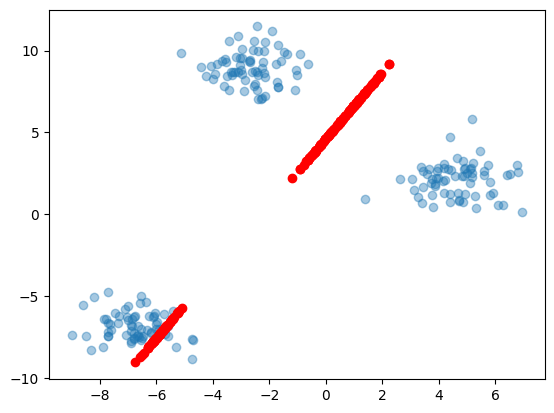

In [4]:
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=200, n_features=2, random_state=42)

pca = PCA(n_components=1)
X_reduced = pca.fit_transform(X)

X_reconstructed = pca.inverse_transform(X_reduced)

plt.scatter(X[:,0], X[:,1], alpha=0.4)
plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1], color='red')
plt.show()

Original points = blue
Projected points = red

---

# Topic 5 — PCA Mathematics (Covariance Matrix & Eigenvectors)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- Section: Principal Component Analysis
- Subsections explaining variance, covariance, and principal axes

> This is the mathematical core of PCA — broken into simple pieces.

---

## 1. Variance (Review)

**Variance** measures how spread out a feature is.

$$\text{Var}(X) = \text{average}\left((x - \bar{x})^2\right)$$

| Variance | Meaning |
|----------|---------|
| Small | Values close together |
| Large | Values widely spread |

**Example:**
```
Dataset A: 5, 6, 5, 6  →  variance small
Dataset B: 1, 10, 2, 9  →  variance large
```

> Large variance = more information.

---

## 2. Covariance

**Covariance** measures the relationship between two variables.

$$\text{Cov}(X, Y) = \text{average}\left((x - \bar{x})(y - \bar{y})\right)$$

| Covariance | Meaning |
|------------|---------|
| Positive | Variables increase together |
| Negative | One increases, the other decreases |
| 0 | No linear relationship |

**Example:** `height ↑ → weight ↑` → Positive covariance.

---

## 3. Covariance Matrix

For multiple features, we compute **all pairwise covariances**.

For a dataset with 3 features $x_1, x_2, x_3$:

$$\Sigma = \begin{bmatrix} \text{Var}(x_1) & \text{Cov}(x_1,x_2) & \text{Cov}(x_1,x_3) \\ \text{Cov}(x_2,x_1) & \text{Var}(x_2) & \text{Cov}(x_2,x_3) \\ \text{Cov}(x_3,x_1) & \text{Cov}(x_3,x_2) & \text{Var}(x_3) \end{bmatrix}$$

**Important properties:**
- **Symmetric matrix**
- **Diagonal = variances**

> This matrix captures how features vary together.

---

## 4. Eigenvectors & Eigenvalues (The PCA Trick)

Once we compute the covariance matrix, PCA finds its **eigenvectors** and **eigenvalues**.

| Concept | Meaning in PCA |
|---------|----------------|
| **Eigenvector** | Direction of a principal component |
| **Eigenvalue** | How much variance that direction captures |

**Example mapping:**
```
Eigenvector1 → PC1
Eigenvector2 → PC2
Eigenvector3 → PC3
```

If eigenvalues are `[5.2, 1.8, 0.3]`:
- **PC1** captures the most variance
- **PC3** captures very little → can be discarded

---

## 5. PCA Algorithm (Step-by-Step)

**Step 1 — Center the data:**
$$X_{\text{centered}} = X - \bar{X}$$

**Step 2 — Compute the covariance matrix:**
$$\Sigma = \text{covariance}(X)$$

**Step 3 — Compute eigenvectors and eigenvalues:**
```
eigenvectors → principal directions
eigenvalues  → variance explained
```

**Step 4 — Sort components by eigenvalue:**
```
largest eigenvalue  → PC1
second largest      → PC2
...
```

**Step 5 — Project data onto top components:**
$$X_{\text{reduced}} = X \times W$$

where $W$ = matrix of selected eigenvectors.

---

## 6. Visual Intuition

**Original axes:**
```
x1
|
|   *
|      *
|        *
|____________ x2
```

**After PCA rotation:**
```
PC2
|
|   *
|      *
|        *
|____________ PC1
```

PC1 now aligns with the direction of **largest spread**.

---

## 🔑 Key Summary

**PCA math steps:**
1. Center the data
2. Compute covariance matrix
3. Compute eigenvectors and eigenvalues
4. Sort by eigenvalues (descending)
5. Project onto top eigenvectors

**Interpretation:**

| Term | Meaning |
|------|---------|
| Eigenvectors | Principal directions |
| Eigenvalues | Amount of variance captured |

---

## ✅ Mini Concept Check

**In PCA, what do eigenvectors represent?**

**Answer: Principal component directions**

$$\text{Eigenvectors} \rightarrow \text{directions of principal components}$$
$$\text{Eigenvalues} \rightarrow \text{amount of variance captured by those directions}$$

> PCA essentially **rotates the coordinate system** so that the new axes (principal components) align with the directions of **greatest variance**.

---

# Topic 6 — Explained Variance Ratio & Choosing Number of Components

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- PCA section discussing explained variance
- Part explaining how many components to keep

---

## 1. Explained Variance

Each principal component explains a **portion of the total variance** in the dataset.

**Example — eigenvalues from PCA:** `[5.2, 2.1, 0.9, 0.2]`

$$\text{Total variance} = 5.2 + 2.1 + 0.9 + 0.2 = 8.4$$

| Component | Eigenvalue | Explained Variance |
|-----------|------------|--------------------|
| PC1 | 5.2 | 5.2 / 8.4 = **62%** |
| PC2 | 2.1 | **25%** |
| PC3 | 0.9 | **11%** |
| PC4 | 0.2 | **2%** |

Keeping **PC1 + PC2** retains $62\% + 25\% = \mathbf{87\%}$ of the dataset's information.

---

## 2. Explained Variance Ratio

$$\text{Explained Variance Ratio} = \frac{\text{eigenvalue}}{\sum \text{all eigenvalues}}$$

> This tells us **how much information** each principal component retains.

---

## 3. Cumulative Explained Variance

| Component | Variance | Cumulative |
|-----------|----------|------------|
| PC1 | 62% | 62% |
| PC2 | 25% | 87% |
| PC3 | 11% | **98%** |
| PC4 | 2% | 100% |

To reach a target of **95% variance**, we keep:
$$PC1 + PC2 + PC3$$

---

## 4. Scree Plot ⭐ (Very Important Visualization)

A **Scree Plot** shows component number vs. explained variance:
```
Variance
 |
 |\
 | \
 |  \
 |   \__________
 |
 +----------------> Components
   1  2  3  4  5
```

The **elbow point** suggests how many components to keep.

> **Rule:** Choose components before variance starts flattening out.

---

## 5. Choosing Number of Components — Practical Rules

| Rule | Description |
|------|-------------|
| **95% Variance Rule** | Keep enough components so cumulative variance ≥ 95% |
| **Elbow Method** | Look for the bend in the scree plot |
| **Visualization Rule** | If plotting, reduce to 2D or 3D |

---

## 🔑 Key Summary

$$\text{Explained Variance Ratio} = \text{how much information each PC retains}$$

$$\text{Cumulative Variance} = \text{total information retained by first } k \text{ components}$$

**Typical rule:**
> Keep components that together explain **≥ 95% of variance**

In [5]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import numpy as np

X, y = load_iris(return_X_y=True)

pca = PCA()
pca.fit(X)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Cumulative variance:")
print(np.cumsum(pca.explained_variance_ratio_))

Explained variance ratio:
[0.92461872 0.05306648 0.01710261 0.00521218]
Cumulative variance:
[0.92461872 0.97768521 0.99478782 1.        ]


Example output:

[0.924, 0.053, 0.017, 0.006]

Cumulative:
[0.924, 0.977, 0.994, 1.0]

Meaning:

PC1 + PC2 explain 97.7% variance

So we could reduce:

4 features → 2 components

with almost no information loss.

---

## ✅ Mini Concept Check

**Given explained variance ratios `[0.70, 0.20, 0.07, 0.02, 0.01]`, how many components retain ≥ 90% variance?**

| Component | Variance | Cumulative |
|-----------|----------|------------|
| PC1 | 0.70 | 0.70 |
| PC2 | 0.20 | **0.90** |
| PC3 | 0.07 | 0.97 |
| PC4 | 0.02 | 0.99 |
| PC5 | 0.01 | 1.00 |

$$PC1 + PC2 = 0.70 + 0.20 = 0.90$$

**✔ Answer: 2 components**

---

# Topic 7 — PCA in Scikit-Learn (Practical Implementation)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- PCA section demonstrating PCA in Python
- Code examples using Scikit-Learn

> This section shows how PCA is actually used in real ML pipelines.

---

## 1. Basic PCA Workflow
```
1. Standardize the data
2. Fit PCA
3. Transform the dataset
```

$$\text{High-dimensional dataset} \rightarrow \text{lower-dimensional dataset}$$

---

## 2. PCA Implementation
```python
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load dataset
X, y = load_iris(return_X_y=True)

# Create PCA object
pca = PCA(n_components=2)

# Fit and transform data
X_reduced = pca.fit_transform(X)

print("Original shape:", X.shape)    # (150, 4)
print("Reduced shape:", X_reduced.shape)  # (150, 2)
```

$$4 \text{ features} \rightarrow 2 \text{ principal components}$$

---

## 3. What `fit_transform()` Does Internally

**Step 1 — `pca.fit(X)`** computes:
- Covariance matrix
- Eigenvectors
- Eigenvalues

**Step 2 — `pca.transform(X)`** projects data onto principal components.

---

## 4. Accessing PCA Information

**Explained Variance Ratio:**
```python
pca.explained_variance_ratio_
# Output: [0.924, 0.053]
```
```
PC1 explains 92.4% variance
PC2 explains  5.3% variance
─────────────────────────────
Total retained: 97.7%
```

**Principal Component Directions:**
```python
pca.components_
# Shape: (2, 4)  →  2 components, 4 original features
```

---

## 5. Automatically Choosing Number of Components

Instead of setting `n_components=2`, pass a variance threshold:
```python
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X)
```

> Scikit-learn will **automatically** select the minimum number of components needed to preserve **95% variance**.

---

## 6. Recommended Production Workflow ⭐

Always **scale features before PCA** using `StandardScaler`:
```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=2))
])

X_reduced = pipeline.fit_transform(X)
```

---

## 🔑 Key Summary

**Practical PCA workflow:**
1. Standardize the data
2. Fit PCA
3. Transform the dataset

| Attribute | Returns |
|-----------|---------|
| `pca.components_` | Principal component directions |
| `pca.explained_variance_ratio_` | Variance explained per component |

**Automatic dimensionality selection:**
```python
PCA(n_components=0.95)  # keeps enough PCs for 95% variance
```

---

## ✅ Mini Concept Check

**Why do we usually standardize features before applying PCA?**

**Answer: To prevent features with larger scales from dominating variance**

> **PCA is variance-based.** If one feature has a much larger scale, it will dominate the principal components.

**Example:**

| Feature | Range |
|---------|-------|
| Age | 0 – 100 |
| Income | 0 – 1,000,000 |

Income would completely dominate PCA unless we scale first.

**Solution — use `StandardScaler` to give all features:**
$$\text{mean} = 0 \qquad \text{std} = 1$$

---

# Topic 8 — Incremental PCA (For Large Datasets)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- Section: Incremental PCA
- Part discussing large datasets that don't fit in memory

---

## 1. The Problem With Standard PCA

Normal PCA requires computing the covariance matrix of the **entire dataset**, meaning it needs everything loaded into RAM at once.

**Example dataset:**
```
10,000,000 samples × 500 features
```
This may not fit in memory → standard PCA becomes **impractical**.

---

## 2. Solution — Incremental PCA

**Incremental PCA (IPCA)** processes the dataset in **batches** instead of all at once:
```
Batch 1 → update model
Batch 2 → update model
Batch 3 → update model
...
```

This allows PCA to scale to very large datasets with drastically reduced memory usage.

---

## 3. Standard PCA vs. Incremental PCA

**Standard PCA:**
```
Entire dataset
      ↓
Compute covariance matrix
      ↓
Compute eigenvectors
```

**Incremental PCA:**
```
Batch 1 → update components
Batch 2 → update components
Batch 3 → update components
Batch 4 → update components
```

---

## 4. When to Use Incremental PCA

Use IPCA when the **dataset does not fit into memory**, for example:

- Image datasets
- Video datasets
- Large log files
- Sensor / streaming data

---

## 5. Implementation in Scikit-Learn
```python
from sklearn.decomposition import IncrementalPCA
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

ipca = IncrementalPCA(n_components=2, batch_size=10)
X_reduced = ipca.fit_transform(X)

print("Reduced shape:", X_reduced.shape)
```

| Parameter | Meaning |
|-----------|---------|
| `n_components` | Number of principal components to keep |
| `batch_size` | Number of samples processed at a time |

---

## 6. Incremental Learning on Large Datasets

For very large datasets, use `partial_fit()` to update components one batch at a time:
```python
for batch in batches:
    ipca.partial_fit(batch)
```

**Example — 1,000,000 samples:**
```
load 1000 rows → partial_fit()
load next 1000 → partial_fit()
repeat until done
```

---

## 🔑 Key Summary

| Method | Memory Requirement |
|--------|--------------------|
| **Standard PCA** | Entire dataset must fit in RAM |
| **Incremental PCA** | Processes data in small batches |

**Key method:**
```python
ipca.partial_fit(batch)  # updates components incrementally
```

> Use **Incremental PCA** whenever your dataset is too large to fit in memory.

---

# Topic 9 — Randomized PCA (Fast PCA for Large Feature Spaces)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- Section: Randomized PCA
- Discussion about faster PCA approximation

---

## 1. The Problem With Standard PCA

Standard PCA requires computing **SVD (Singular Value Decomposition)**. For high-dimensional data this becomes very expensive:

**Example dataset:**
```
n_samples  = 100,000
n_features =  10,000
```

**Time complexity grows roughly with:**
$$O\left(\min(n\_samples^2 \times n\_features,\ n\_features^2 \times n\_samples)\right)$$

---

## 2. Randomized PCA — The Idea

Randomized PCA uses **random projections** to *approximate* principal components rather than computing them exactly.

| Method | Speed | Accuracy |
|--------|-------|----------|
| **Standard PCA** | Slow (exact SVD) | Exact |
| **Randomized PCA** | Much faster | Near-identical approximation |

---

## 3. Intuition

Imagine a dataset with **10,000 dimensions**, but the true structure lives in only **10 important directions**.

Randomized PCA uses random sampling to quickly identify those directions without scanning every dimension in detail.

> Think of it like estimating city traffic by randomly sampling streets instead of measuring every road — you still get a very good estimate.

---

## 4. When Randomized PCA is Useful

Best used when:
$$\text{number of features} \gg \text{number of components needed}$$

**Example:**
```
10,000 features  →  keep only 50 components
```

Common domains:
- Image processing
- Text embeddings
- Genomics
- NLP datasets

---

## 5. Implementation in Scikit-Learn
```python
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

pca = PCA(n_components=2, svd_solver="randomized")
X_reduced = pca.fit_transform(X)

print("Reduced shape:", X_reduced.shape)
```

> Scikit-learn also **automatically switches** to randomized SVD internally when the dataset is large and the number of components requested is small — so in many real projects `PCA()` becomes Randomized PCA without any extra configuration.

---

## 🔑 Key Summary

| | |
|--|--|
| **Purpose** | Speed up PCA computation on large feature spaces |
| **Idea** | Use random projections to approximate principal components |
| **Best used when** | `n_features >> n_components` needed |
| **Parameter** | `svd_solver="randomized"` |

**Example scenario:**
```
10,000 features → keep 50 components
```
Randomized PCA gives **similar results** to standard PCA at **much faster** computation speed.

---

# Topic 10 — Kernel PCA (Non-Linear Dimensionality Reduction)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- Section: Kernel PCA
- Figures showing non-linear structures like the Swiss Roll

> This is where dimensionality reduction becomes much more powerful — because standard PCA has a major limitation.

---

## 1. The Limitation of Standard PCA

Standard PCA assumes the data lies near a **linear subspace** (near a plane or line). This works well for linear structure, but many real datasets are **non-linear**.

**Example — Swiss Roll dataset:**
```
A sheet of paper rolled into a spiral.
Projecting with normal PCA causes the structure
to overlap and important relationships are lost.
```

---

## 2. Kernel PCA — The Solution

**Key idea:**

$$\text{Map data into a higher-dimensional space where the structure becomes linear}$$

Then apply standard PCA in that transformed space.

---

## 3. The Kernel Trick

Instead of explicitly computing the high-dimensional transformation, Kernel PCA uses a **kernel function** $K(x, y)$ that measures similarity between points.

| Kernel | Use Case |
|--------|----------|
| **Linear** | Same as normal PCA |
| **Polynomial** | Captures curved relationships |
| **RBF (Gaussian)** | Most common non-linear kernel |
| **Sigmoid** | Neural network-style separations |

---

## 4. Intuition

**Original non-linear structure — a circle:**
```
   *   *
 *       *
 *       *
   *   *
```
Linear PCA cannot flatten this properly.

**Kernel PCA transforms the data** so the circle becomes **linearly separable** in higher dimensions — effectively "unrolling" a spiral into a straight-line structure while preserving neighborhood relationships between points.

---

## 5. Implementation in Scikit-Learn
```python
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=400, factor=0.3, noise=0.05)

kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)
X_reduced = kpca.fit_transform(X)
```

| Parameter | Meaning |
|-----------|---------|
| `n_components` | Number of dimensions after reduction |
| `kernel` | Type of kernel function to use |
| `gamma` | Controls RBF kernel flexibility |

---

## 6. When to Use Kernel PCA

✅ Use when data has **non-linear structure**, e.g.:
- Image manifolds
- Shape recognition
- Complex embeddings

⚠️ **Drawback:** Computationally expensive for very large datasets.

---

## 🔑 Key Summary

| | |
|--|--|
| **Problem** | Standard PCA only captures linear structure |
| **Solution** | Map data to higher-dimensional space where non-linear patterns become linear |
| **Technique** | Kernel trick via $K(x, y)$ |
| **Common kernels** | Linear, Polynomial, RBF, Sigmoid |
```python
KernelPCA(n_components=2, kernel="rbf", gamma=15)
```

---

# Topic 11 — Manifold Learning

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- Section: Manifold Learning
- Examples like Swiss Roll dataset

> This concept explains why non-linear dimensionality reduction methods exist.

---

## 1. The Manifold Hypothesis

One of the most important ideas in modern machine learning:

> **High-dimensional data often lies on a much lower-dimensional manifold.**

**What is a Manifold?** A surface embedded in a higher-dimensional space.

| Object | Intrinsic Dimension | Space |
|--------|---------------------|-------|
| Line | 1D | 2D or 3D |
| Sheet of paper | 2D | 3D |
| Swiss Roll | 2D | 3D |
```
3D space

      ______
    /      /
  /______/      ← rolled sheet (intrinsic structure is 2D)
```

---

## 2. Why Projection Methods Fail

Methods like PCA assume data lies near a **flat surface**. But manifolds can be **curved**.

**Example — Swiss Roll projected with PCA:**
```
the layers overlap → neighborhood relationships are destroyed
```

---

## 3. Goal of Manifold Learning

Manifold learning tries to **unfold the manifold** so the data becomes flat, while preserving **local distances between points**.

$$\text{Swiss Roll (3D)} \rightarrow \text{Unrolled sheet (2D)}$$

> Think of it like unrolling a rolled carpet back into a flat sheet — the structure becomes easy to analyze.

---

## 4. Popular Manifold Learning Algorithms

| Algorithm | Core Idea |
|-----------|-----------|
| **LLE** (Locally Linear Embedding) | Preserves local relationships |
| **Isomap** | Preserves geodesic distances |
| **t-SNE** | Excellent for visualization |
| **UMAP** | Modern, fast manifold learning |

> Chapter 8 focuses mainly on **LLE (Locally Linear Embedding)**.

---

## 5. Why Manifold Learning Matters

Real-world datasets often lie on manifolds despite having thousands of features:

**Example — Face image:**
```
10,000 pixels in feature space
```
But variation mainly comes from just:
```
lighting  |  pose  |  expression
```
So the **intrinsic dimension is much smaller** than 10,000.

Other examples: speech signals, motion data, text embeddings.

---

## 🔑 Key Summary

| Method | Works For |
|--------|-----------|
| **PCA / Projection** | Flat (linear) structures |
| **Manifold Learning** | Curved (non-linear) structures |

**Manifold Hypothesis:**
> High-dimensional data lies on a lower-dimensional manifold.

$$\text{Swiss Roll (curved, 3D)} \xrightarrow{\text{manifold learning}} \text{flat rectangle (2D)}$$

---

# Topic 12 — Locally Linear Embedding (LLE)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf**
- Section: Locally Linear Embedding (LLE)
- Figures showing Swiss Roll unfolding

> This is the main manifold learning algorithm explained in Chapter 8.

---

## 1. Core Idea of LLE

> **Each data point can be reconstructed from its nearest neighbors.**

This works because **manifolds are locally linear** — even if the overall structure is curved, small neighborhoods look almost flat:
```
Large curved surface  →  curved
Small patch of that surface  →  almost flat
```

---

## 2. LLE Algorithm (Step-by-Step)

**Step 1 — Find Nearest Neighbors**

For each data point $x_i$, find its $k$ nearest neighbors:
```
point xi  →  neighbors: x1, x2, x3
```

**Step 2 — Compute Reconstruction Weights**

Reconstruct each point as a weighted sum of its neighbors:

$$x_i \approx w_1 x_1 + w_2 x_2 + w_3 x_3$$

Subject to the constraint:
$$w_1 + w_2 + w_3 = 1$$

These weights **capture the local geometry**.

**Step 3 — Find Lower-Dimensional Representation**

Find new coordinates in lower dimensions such that the **same reconstruction weights are preserved**:

$$\text{local structure in 3D} \rightarrow \text{local structure in 2D}$$

---

## 3. Visual Intuition
```
Swiss Roll (3D spiral)
        ↓  LLE
Flat 2D sheet
```

Local neighbors remain neighbors after unfolding. The manifold unrolls correctly because small neighborhoods were approximately linear all along.

---

## 4. Implementation in Scikit-Learn
```python
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.datasets import make_swiss_roll

X, t = make_swiss_roll(n_samples=1000)

lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=10
)

X_reduced = lle.fit_transform(X)

print("Original shape:", X.shape)     # (1000, 3)
print("Reduced shape:", X_reduced.shape)  # (1000, 2)
```

$$\text{3D manifold} \rightarrow \text{2D representation}$$

---

## 5. The `n_neighbors` Parameter

| Value | Effect |
|-------|--------|
| Small (e.g. `5`) | Tighter local neighborhoods |
| Large (e.g. `20`) | Broader local neighborhoods |

> Choosing the right value is important — too small misses structure, too large over-smooths it.

---

## 6. When LLE Works Well vs. Struggles

| ✅ Works Well | ⚠️ Struggles |
|--------------|--------------|
| Data on a smooth manifold | Very noisy datasets |
| Image pose variations | Extremely complex manifolds |
| Robot motion / sensor data | Very large datasets (costly neighbor search) |

---

## 🔑 Key Summary

| Step | Action |
|------|--------|
| **1** | Find $k$ nearest neighbors for each point |
| **2** | Compute reconstruction weights from neighbors |
| **3** | Find lower-dimensional layout that preserves those weights |

> **Goal:** Preserve **local geometry** of the manifold — not global distances.

$$\text{Manifold (curved, high-D)} \xrightarrow{\text{LLE}} \text{Flat representation (low-D)}$$

---

# 📘 Chapter 8 — Dimensionality Reduction (Complete Master Notes)

## 📍 Where to Read
**8_Dimensionality Reduction.pdf** — Entire chapter (Dimensionality Reduction overview, PCA, Kernel PCA, Manifold Learning, LLE)

---

## 1. What is Dimensionality?

$$\text{Dimensionality} = \text{number of features (variables) in a dataset}$$

**Example:** Height, Weight, Age → **3 dimensions**

| Features | Space |
|----------|-------|
| 1 | Line |
| 2 | Plane |
| 3 | 3D space |
| 100 | 100-dimensional space |

---

## 2. Dimensionality Reduction

**Dimensionality reduction** reduces the number of features while preserving important information.

$$100 \text{ features} \rightarrow 10 \text{ features (most information preserved)}$$

---

## 3. Why Dimensionality Reduction is Important

**① Faster Training** — Reducing features speeds up training dramatically:
$$1000 \text{ features} \rightarrow 50 \text{ features}$$

**② Data Visualization** — Humans can only visualize 2D/3D, so:
$$100\text{D dataset} \rightarrow \text{2D plot (clusters, outliers, patterns become visible)}$$

**③ Curse of Dimensionality** — As dimensions increase, space grows exponentially and data becomes sparse:

| Dimension | Samples Needed |
|-----------|---------------|
| 1D | 100 |
| 2D | 100² |
| 10D | 100¹⁰ |

Consequences: nearest neighbors become far apart, distance metrics lose meaning, models overfit.

---

## 4. Projection Methods

Project data onto a lower-dimensional subspace, assuming data lies near a lower-dimensional plane:

$$\text{3D data (near a 2D plane)} \rightarrow \text{project to 2D}$$

---

## 5. Principal Component Analysis (PCA)

PCA finds **directions of maximum variance** and projects data onto them. These directions are called **Principal Components**.

| Component | Direction |
|-----------|-----------|
| **PC1** | Maximum variance |
| **PC2** | Second largest variance |
| **PC3** | Third largest variance |

$$PC1 \perp PC2 \perp PC3 \quad \text{(all orthogonal, 90° apart)}$$

---

## 6. PCA Dimensionality Reduction — Example

| Component | Variance |
|-----------|----------|
| PC1 | 60% |
| PC2 | 25% |
| PC3 | 10% |
| Others | 5% |

Keeping PC1 + PC2 + PC3 retains **95% variance**:
$$100 \text{ features} \rightarrow 3 \text{ components}$$

---

## 7. PCA Optimization Goal

$$\text{Maximize variance of projected data} \iff \text{Minimize reconstruction error}$$

Where reconstruction error = distance between original and reconstructed points.

---

## 8. PCA Mathematics (Step-by-Step)

**Step 1 — Center the data:**
$$X_{\text{centered}} = X - \bar{X}$$

**Step 2 — Compute covariance matrix:**
$$\Sigma = \text{covariance}(X)$$

**Step 3 — Eigen Decomposition:**

| Concept | Meaning |
|---------|---------|
| Eigenvectors | Principal component directions |
| Eigenvalues | Variance captured |

**Step 4 — Sort by eigenvalue:** largest → PC1, second → PC2 ...

**Step 5 — Project data:**
$$X_{\text{reduced}} = X \times W \quad \text{where } W = \text{selected eigenvectors}$$

---

## 9. Explained Variance Ratio

$$\text{Explained Variance Ratio} = \frac{\text{eigenvalue}}{\sum \text{all eigenvalues}}$$

**Example:** `[0.70, 0.20, 0.07, 0.02, 0.01]`

| Components Kept | Cumulative Variance |
|-----------------|---------------------|
| PC1 | 70% |
| PC1 + PC2 | 90% |
| PC1 + PC2 + PC3 | 97% |

> **Typical rule:** retain ≥ 95% variance.

---

## 10. PCA in Scikit-Learn
```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
```

| Attribute | Returns |
|-----------|---------|
| `pca.components_` | Principal component directions |
| `pca.explained_variance_ratio_` | Variance explained per component |
```python
# Automatic component selection
pca = PCA(n_components=0.95)  # keeps enough PCs for 95% variance
```

---

## 11. Feature Scaling Before PCA ⭐

PCA is **variance-based** — unscaled features with large ranges dominate.

| Feature | Range |
|---------|-------|
| Age | 0 – 100 |
| Income | 0 – 1,000,000 |

**Solution:** Always use `StandardScaler` first → mean = 0, std = 1.
```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])
```

---

## 12. Incremental PCA

**Problem:** Standard PCA requires the entire dataset in RAM.

**Solution:** Incremental PCA processes data in **batches**:
```python
from sklearn.decomposition import IncrementalPCA

ipca = IncrementalPCA(n_components=2, batch_size=100)

for batch in batches:
    ipca.partial_fit(batch)  # updates components incrementally
```

---

## 13. Randomized PCA

Approximates principal components using **random projections** — much faster than exact SVD.
```python
pca = PCA(n_components=2, svd_solver="randomized")
```

Best when: $n\_features \gg n\_components$ (e.g. 10,000 features → keep 50 components).

---

## 14. Kernel PCA

**Problem:** Standard PCA only captures linear structure (fails on Swiss Roll, circles, spirals).

**Solution:** Map data to a higher-dimensional space where the non-linear structure becomes linear, using the **kernel trick**.

| Kernel | Use Case |
|--------|----------|
| Linear | Standard PCA |
| Polynomial | Curved relationships |
| RBF | Most common non-linear |
| Sigmoid | Neural-style mapping |
```python
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)
```

---

## 15. Manifold Hypothesis

> **High-dimensional data often lies on a much lower-dimensional manifold.**

Even if a dataset has 1,000 features, the **intrinsic dimension** may be only 10 (e.g. face images vary mainly by lighting, pose, expression).

---

## 16. Manifold Learning

**Goal:** Flatten curved manifolds while preserving local structure.

$$\text{Swiss Roll (3D, curved)} \xrightarrow{\text{manifold learning}} \text{Flat sheet (2D)}$$

---

## 17. Locally Linear Embedding (LLE)

> **Each point can be reconstructed from its nearest neighbors.**

**Step 1 — Find nearest neighbors:** $k$ neighbors for each point $x_i$

**Step 2 — Compute reconstruction weights:**
$$x_i \approx w_1 x_1 + w_2 x_2 + w_3 x_3 \quad \text{where } \sum w = 1$$

**Step 3 — Find lower-dimensional layout** preserving those same weights.
```python
from sklearn.manifold import LocallyLinearEmbedding
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10)
X_reduced = lle.fit_transform(X)
```

---

## 18. When to Use Each Method

| Method | Use Case |
|--------|----------|
| **PCA** | Linear dimensionality reduction |
| **Incremental PCA** | Dataset too large for memory |
| **Randomized PCA** | Very high feature counts |
| **Kernel PCA** | Non-linear dimensionality reduction |
| **LLE** | Manifold learning / curved data |

---

## 19. Full Chapter Mental Map
```
Dimensionality Reduction
        │
        ├── Projection Methods
        │        └── PCA
        │              ├── variance maximization
        │              ├── eigenvectors
        │              ├── explained variance
        │              ├── Incremental PCA
        │              └── Randomized PCA
        │
        └── Nonlinear Methods
                 ├── Kernel PCA
                 └── Manifold Learning
                          └── LLE
```

---

## ⭐ Most Important Concepts (Exam / Interview)

1. Curse of dimensionality
2. PCA — principal components & variance maximization
3. Explained variance ratio
4. Feature scaling before PCA
5. Kernel PCA vs. standard PCA
6. Manifold hypothesis
7. LLE algorithm

---

# 📝 Chapter 8 — Exercises

---

**Q1. What are the main motivations for reducing a dataset's dimensionality? What are the main drawbacks?**

**Motivations:**
- Speed up training and reduce computational cost
- Reduce storage requirements
- Enable visualization of high-dimensional data in 2D/3D
- Mitigate the curse of dimensionality, which can improve generalization

**Drawbacks:**
- Potential information loss
- Reduced model accuracy if important features are removed
- Reduced interpretability — new features (like principal components) may not have clear real-world meanings

---

**Q2. What is the curse of dimensionality?**

As the number of dimensions increases, the feature space grows **exponentially** and data becomes **sparse**. Distances between points lose meaning, patterns become harder to find, and much larger datasets are required to maintain data density.

---

**Q3. Once a dataset's dimensionality has been reduced, is it possible to reverse the operation?**

**Approximately yes, but not perfectly.** Methods like PCA allow partial reconstruction via inverse transformation, but because information is discarded during reduction, the reconstruction will always contain some loss and cannot fully recover the original data.

---

**Q4. Can PCA be used to reduce the dimensionality of a highly nonlinear dataset?**

**Standard PCA cannot** — it only captures linear relationships. However, **Kernel PCA** handles nonlinear structures by implicitly mapping data into a higher-dimensional space where linear PCA can then be applied effectively.

---

**Q5. Suppose you perform PCA on a 1,000-dimensional dataset, setting the explained variance ratio to 95%. How many dimensions will the resulting dataset have?**

**It cannot be known in advance.** The number depends entirely on how variance is distributed across features. PCA will automatically select the minimum number of components needed to retain ≥ 95% of total variance — which could be anywhere from a handful to hundreds.

---

**Q6. In what cases would you use vanilla PCA, Incremental PCA, Randomized PCA, or Kernel PCA?**

| Method | When to Use |
|--------|-------------|
| **Vanilla PCA** | Standard reduction on datasets that fit in memory |
| **Incremental PCA** | Dataset too large for RAM — processed in batches |
| **Randomized PCA** | Very high-dimensional data, only small number of components needed |
| **Kernel PCA** | Data contains nonlinear structures linear PCA cannot capture |

---

**Q7. How can you evaluate the performance of a dimensionality reduction algorithm?**

- Measure **variance preserved** (for PCA-based methods via `explained_variance_ratio_`)
- Calculate **reconstruction error** by inverting the transformation and comparing to original data
- Check **downstream task performance** — does classification or clustering improve or hold up with the reduced dataset?

---

**Q8. Does it make sense to chain two different dimensionality reduction algorithms?**

**Yes.** A common and effective pattern is to use **PCA first** to reduce noise and cut down dimensions cheaply, then apply a nonlinear method like **LLE or t-SNE** on the smaller dataset. This improves both efficiency and the quality of the final embedding, especially on very high-dimensional data.

---

# 🧪 Exercise 9 — MNIST + PCA + Random Forest Experiment

---

## Step 1 — Load MNIST and Split Data
```python
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

mnist = fetch_openml('mnist_784', version=1)
X = mnist.data
y = mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
```
```
Samples: 70,000  |  Features: 784 (28×28 pixels)
Training: 60,000  |  Testing: 10,000
```

---

## Step 2 — Train Random Forest on Original Dataset
```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

rf = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Training time:", train_time)
print("Accuracy:", accuracy)
```

**Typical results:**
```
Training time ≈ 40–60 seconds
Accuracy      ≈ 96–97%
```

---

## Step 3 — Apply PCA (95% Variance)
```python
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_reduced = pca.fit_transform(X_train)
X_test_reduced  = pca.transform(X_test)

print("Original dimensions:", X_train.shape[1])
print("Reduced dimensions: ", X_train_reduced.shape[1])
```

**Typical result:**
$$784 \text{ features} \rightarrow \sim 154 \text{ features} \quad (\approx 80\% \text{ reduction})$$

---

## Step 4 — Train Random Forest on Reduced Dataset
```python
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
rf_pca.fit(X_train_reduced, y_train)
train_time_pca = time.time() - start

y_pred_pca = rf_pca.predict(X_test_reduced)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print("Training time with PCA:", train_time_pca)
print("Accuracy with PCA:     ", accuracy_pca)
```

**Typical results:**
```
Training time ≈ 20–30 seconds
Accuracy      ≈ 94–95%
```

---

## Comparison

| Model | Features | Training Time | Accuracy |
|-------|----------|---------------|----------|
| Random Forest (original) | 784 | ~50 sec | ~96–97% |
| Random Forest + PCA | ~154 | ~25 sec | ~94–95% |

## Conclusion

> PCA reduced features by ~80%, cutting training time roughly in half. Accuracy dropped slightly (~1–2%) because some information is lost during compression — a classic **speed vs. accuracy trade-off**.

---
---

# 🧪 Exercise 10 — t-SNE Visualization of MNIST + Comparison with PCA / LLE / MDS

---

## A) Load MNIST and Sample (Important for Speed)

t-SNE is computationally expensive — always work with a random subset.
```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

# Take a manageable sample
rng = np.random.default_rng(42)
n   = 6000
idx = rng.choice(len(X), size=n, replace=False)
X_s = X[idx]
y_s = y[idx]
```

---

## B) t-SNE → 2D Scatter Plot (10 colors)

> **Tip:** Pre-reduce to ~50 dims with PCA before t-SNE — faster and less noisy.
```python
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Pre-reduce with PCA (recommended)
X_50 = PCA(n_components=50, random_state=42).fit_transform(X_s)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_tsne = tsne.fit_transform(X_50)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_s, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("MNIST t-SNE (2D)")
plt.axis("off")
plt.show()
```

**Expected outcome:** Clear, well-separated clusters for most digits, with some overlap (e.g. 4/9, 3/5).

---

## C) Optional — Colored Digit Labels
```python
plt.figure(figsize=(12, 10))
for digit in range(10):
    mask = (y_s == digit)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=8, alpha=0.6, label=str(digit))
plt.legend(title="Digit", markerscale=2)
plt.title("MNIST t-SNE (colored clusters)")
plt.axis("off")
plt.show()
```

---

## D) Optional — Digit Thumbnails with Anti-Clutter Logic

Only plots an image if it's not too close to an already-plotted one.
```python
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

def plot_thumbnails(X_2d, X_imgs, min_dist=3.0, zoom=0.6):
    plt.figure(figsize=(12, 10))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c="lightgray", s=5, alpha=0.4)
    shown = np.array([[1e9, 1e9]])

    for i in range(X_2d.shape[0]):
        dist = np.min(np.sum((X_2d[i] - shown)**2, axis=1))
        if dist < min_dist**2:
            continue
        shown = np.vstack([shown, X_2d[i]])
        img = X_imgs[i].reshape(28, 28)
        ab  = AnnotationBbox(OffsetImage(img, cmap="gray", zoom=zoom),
                             (X_2d[i, 0], X_2d[i, 1]), frameon=False)
        plt.gca().add_artist(ab)

    plt.title("MNIST t-SNE with digit thumbnails (anti-clutter)")
    plt.axis("off")
    plt.show()

plot_thumbnails(X_tsne, X_s, min_dist=3.0, zoom=0.5)
```

---

## E) Comparison — PCA, LLE, and MDS

**① PCA → 2D (fastest)**
```python
X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_s)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_s, cmap="tab10", s=8, alpha=0.7)
plt.title("MNIST PCA (2D)")
plt.axis("off")
plt.show()
```

**② LLE → 2D**
```python
from sklearn.manifold import LocallyLinearEmbedding

lle    = LocallyLinearEmbedding(n_components=2, n_neighbors=20, random_state=42)
X_lle2 = lle.fit_transform(X_s)

plt.figure(figsize=(10, 8))
plt.scatter(X_lle2[:, 0], X_lle2[:, 1], c=y_s, cmap="tab10", s=8, alpha=0.7)
plt.title("MNIST LLE (2D)")
plt.axis("off")
plt.show()
```

**③ MDS → 2D (slow — use smaller sample)**
```python
from sklearn.manifold import MDS

n_mds      = 2000
idx2       = rng.choice(len(X_s), size=n_mds, replace=False)
X_mds_in   = X_s[idx2]
y_mds      = y_s[idx2]
X_mds_50   = PCA(n_components=50, random_state=42).fit_transform(X_mds_in)

mds    = MDS(n_components=2, random_state=42, n_init=1,
             max_iter=150, normalized_stress="auto")
X_mds2 = mds.fit_transform(X_mds_50)

plt.figure(figsize=(10, 8))
plt.scatter(X_mds2[:, 0], X_mds2[:, 1], c=y_mds, cmap="tab10", s=10, alpha=0.7)
plt.title("MNIST MDS (2D) — smaller sample")
plt.axis("off")
plt.show()
```

---

## F) Conclusion — Method Comparison

| Method | Speed | Cluster Separation | Notes |
|--------|-------|--------------------|-------|
| **t-SNE** | Slow | ⭐⭐⭐ Best | Preserves local neighborhoods; sensitive to perplexity/seed |
| **PCA** | ⭐ Fastest | Poor (overlap) | Preserves global variance, not class separation |
| **LLE** | Medium | Moderate | Sensitive to `n_neighbors` and noise |
| **MDS** | Very slow | Moderate | Preserves pairwise distances; less scalable |